In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(50000, 32, 32, 3)


In [3]:
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_test = (x_test.astype("float32") - 127.5) / 127.5


In [4]:
x_train_gray = tf.image.rgb_to_grayscale(x_train)
x_test_gray = tf.image.rgb_to_grayscale(x_test)


Input → grayscale image
Output → color image


In [6]:
from tensorflow.keras import layers

model = tf.keras.Sequential([

layers.Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(32,32,1)),
layers.MaxPooling2D((2,2)),

layers.Conv2D(64,(3,3),activation="relu",padding="same"),
layers.MaxPooling2D((2,2)),

layers.Conv2D(128,(3,3),activation="relu",padding="same"),

layers.UpSampling2D((2,2)),
layers.Conv2D(64,(3,3),activation="relu",padding="same"),

layers.UpSampling2D((2,2)),
layers.Conv2D(3,(3,3),activation="tanh",padding="same")

])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
optimizer="adam",
loss="mse"
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,195 (657.01 KB)

 Trainable params: 168,195 (657.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.fit(
x_train_gray,
x_train,
epochs=10,
batch_size=64,
validation_data=(x_test_gray,x_test)
)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 421s 534ms/step - loss: 0.0418 - val_loss: 0.0339
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 441s 565ms/step - loss: 0.0317 - val_loss: 0.0298
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 418s 534ms/step - loss: 0.0292 - val_loss: 0.0297
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 450s 544ms/step - loss: 0.0280 - val_loss: 0.0273
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 439s 540ms/step - loss: 0.0272 - val_loss: 0.0266
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 440s 537ms/step - loss: 0.0266 - val_loss: 0.0257
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 425s 543ms/step - loss: 0.0262 - val_loss: 0.0256
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 427s 547ms/step - loss: 0.0258 - val_loss: 0.0253
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 427s 546ms/step - loss: 0.0255 - val_loss: 0.0255
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 420s 537ms/step - loss: 0.0253 - val_loss: 0.0277


In [9]:
pred = model.predict(x_test_gray[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step


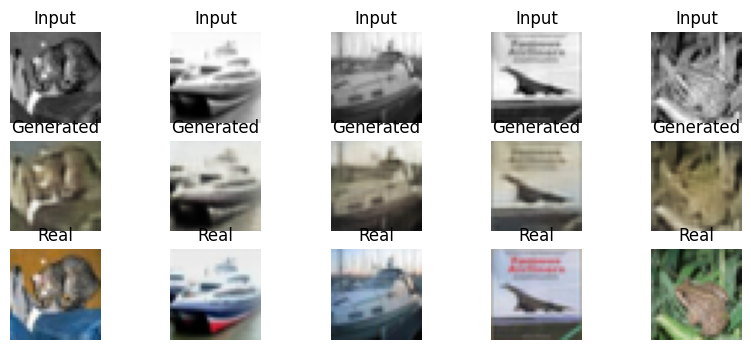

In [11]:
plt.figure(figsize=(10,4))

for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(tf.squeeze(x_test_gray[i]), cmap="gray")
    plt.axis("off")
    plt.title("Input")

    plt.subplot(3,5,i+6)
    plt.imshow((pred[i]+1)/2)
    plt.axis("off")
    plt.title("Generated")

    plt.subplot(3,5,i+11)
    plt.imshow((x_test[i]+1)/2)
    plt.axis("off")
    plt.title("Real")

plt.show()


In [12]:
img = (pred[0]+1)/2

plt.imsave("translated_image.png",img)


In [13]:
from google.colab import files
files.download("translated_image.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>